# Stochastic benchmarking

In this notebook we compare how well different methods recover:
1) Mean final size of failed epidemics
2) Mean and SD of successful final size distribution (assuming central limit theorem)
3) Probability of epidemic extinction

First some messy functions to read in the data....

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from standard_results import final_size_success_mean, final_size_success_sd, probability_failure, final_size_failed_mn

def float_to_str(x, precision=6):
    s = f"{x:.{precision}f}".rstrip('0').rstrip('.')
    return s.replace('.', 'p')

def params_to_filename(params):
    parts = []
    for key in params:
        val = params[key]
        if isinstance(val, float):
            val = float_to_str(val)
        parts.append(f"{key}_{val}")
    return "__".join(parts)

def read_data(R0, trec, N, method, params=None, param_name=None):
    epi_params = {"R0": R0, "trec": trec, "N": N}

    results = []

    # Tau leap

    if param_name is not None:
        for param in params:
            parameters = {param_name: param}
            fname = params_to_filename( parameters | epi_params )
            results.append(pd.read_csv(f"out/{method}__{fname}.csv"))

        return {"R0": R0, "results": results}
    else:
        fname = params_to_filename(epi_params)
        results.append(pd.read_csv(f"out/{method}__{fname}.csv"))

        return {"R0": R0, "results": results}        

trec=4.0
N=100000

R0s = [1.2, 2.0]

fixed_outs = []
for R0 in R0s:
    fixed_outs.append(read_data(R0, trec, N, "tau_fixed", [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0], "tau"))

adapt_outs = []
for R0 in R0s:
    adapt_outs.append(read_data(R0, trec, N, "tau_adaptive", [0.01, 0.03, 0.1, 0.3], "epsilon"))

exact_outs = []
for R0 in R0s:
    exact_outs.append(read_data(R0, trec, N, "direct"))

Process data

In [132]:
def build_df(out):
    cutoff = 1000
    R0 = out["R0"]
    results = out["results"]

    rows = []

    for result in results:
        sizes = result['final_size']
        failures = sizes[sizes < cutoff]
        successes = sizes[sizes >= cutoff]

        mn_fail_size_obs = failures.mean()
        sd_fail_size_obs = failures.std()
        mn_success_size_obs = successes.mean()
        sd_success_size_obs = successes.std()
        p_fail_obs = len(failures) / len(sizes)

        filtered = result[result['final_size'] > cutoff]
        cpu_time = filtered['cpu_time_seconds'].mean()

        method = result['method'].iloc[0]

        if method != "direct":
            param_name = result.columns[-1]
            param_value = result.iloc[0, -1]
        else:
            param_name = "exact"
            param_value = 1
        
        row = {
            "method": method,
            "R0": R0,
            "param_name": param_name,
            "param_value": param_value,
            "mn_fail": mn_fail_size_obs,
            "sd_fail": sd_fail_size_obs,
            "mn_success": mn_success_size_obs,
            "sd_success": sd_success_size_obs,
            "p_fail": p_fail_obs,
            "cpu_time": cpu_time
            }
        
        rows.append(row)
        
    return rows

rows = []

for out in adapt_outs:
    rows += build_df(out)
for out in fixed_outs:
    rows += build_df(out)
for out in exact_outs:
    rows += build_df(out)

df = pd.DataFrame(rows)

df

,method,R0,param_name,param_value,mn_fail,sd_fail,mn_success,sd_success,p_fail,cpu_time
0,tau_adaptive,1.2,epsilon,0.01,8.916004,22.842871,31403.956640,1192.508667,0.7417,0.718768
1,tau_adaptive,1.2,epsilon,0.03,9.025421,22.247189,31753.343626,1214.929909,0.7474,0.209428
2,tau_adaptive,1.2,epsilon,0.10,9.062669,23.614291,32236.825804,1161.408833,0.7388,0.055052
3,tau_adaptive,1.2,epsilon,0.30,7.330217,17.600228,32546.842260,1047.979315,0.7274,0.024028
4,tau_adaptive,2.0,epsilon,0.01,2.363969,2.906067,79829.783763,289.398765,0.3558,0.231515
5,tau_adaptive,2.0,epsilon,0.03,2.438831,2.928621,80124.971746,287.474968,0.3523,0.099578
6,tau_adaptive,2.0,epsilon,0.10,2.406780,2.895628,81204.327342,282.625842,0.3658,0.034248
7,tau_adaptive,2.0,epsilon,0.30,2.427852,2.885575,83482.134963,398.842401,0.3576,0.011702
8,tau_fixed,1.2,tau,0.01,6.007434,19.195261,31346.637952,1174.354341,0.8340,1.497364
9,tau_fixed,1.2,tau,0.02,5.667907,16.880752,31362.504197,1183.168625,0.8332,1.189486


In [133]:
# Targets
targets = {}
for i, R0 in enumerate(R0s):
    mn_fail = final_size_failed_mn(R0)
    mn_norm = final_size_success_mean(R0)
    mn = mn_norm * N
    p_fail = probability_failure(R0)
    sd = df[ (df['method']=="direct") & (df['R0']==R0) ]['sd_success'].iloc[0]
    targets[R0] = {"mn_fail": mn_fail, "mn_success": mn, "sd_success": sd, "p_fail": p_fail}

C:\Users\Joseph.Gibson\AppData\Local\Temp\ipykernel_22920\3280128351.py:28: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axis.set_yscale("log")


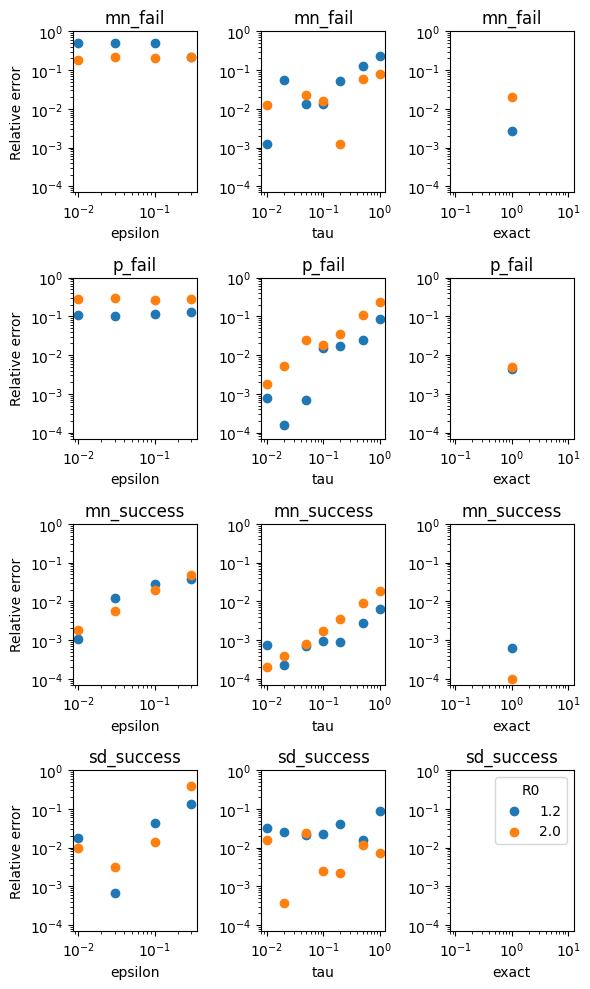

In [134]:
fig, ax = plt.subplots(4, 3, figsize = (6,10))

methods = df['method'].unique()

vals = ['mn_fail', 'p_fail', 'mn_success', 'sd_success'] 

for i, method in enumerate(methods):
    dat = df[df['method']==method]
    
    for R0 in R0s:
        dat2 = dat[dat['R0']==R0]

        if method !="direct":
            for j, val in enumerate(vals):
                y = dat2[val]
                err = abs(y - targets[R0][val]) / targets[R0][val]
                ax[j][i].scatter(dat2['param_value'], err, label=R0)
                ax[j][i].set_title(val)
        else:
            for j, val in enumerate(vals):
                y = dat2[val]
                err = abs(y - targets[R0][val]) / targets[R0][val]
                ax[j][i].scatter(1, err, label=R0)
                ax[j][i].set_title(val)

        for axis in ax[:,i]:
            axis.set_xscale("log")
            axis.set_yscale("log")
            axis.set_ylim(.7e-4, 1e0)
            axis.set_xlabel(dat2['param_name'].iloc[0])

for axis in ax[:,0]:
    axis.set_ylabel("Relative error")

ax[-1,-1].legend(title="R0")

plt.tight_layout()
plt.show()

## Compare relative errors of each method:

Adaptive tau leap methods hit an accuracy limit for extinction probability. The reason why has been covered in the adaptive_tau_steps notebook.

Mean final size is well recovered with all methods (rel error approx $10^{-3}$).

Standard deviation is not recovered for any methods, but this is due to the (quasi)analytic target value not being very accurate itself. (maybe use exact method to provide target).

Since there is no way to directly compare methods (how do taus correspond with epsilons, for example) we need to see how long each method takes:

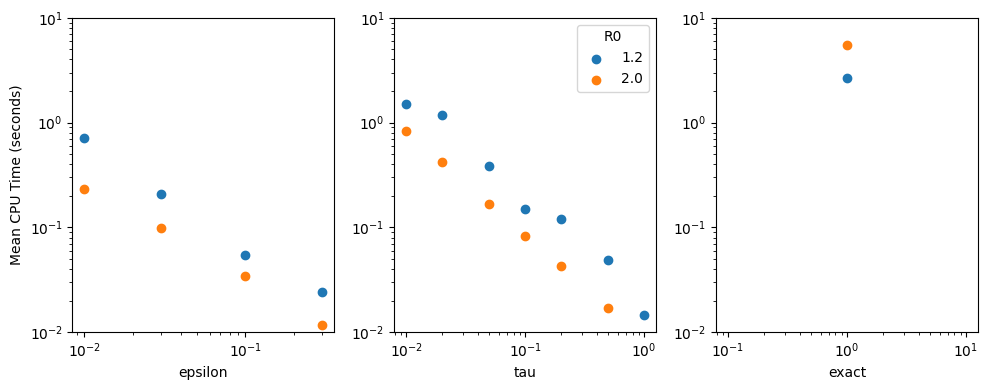

In [135]:
fig, ax = plt.subplots(1,3, figsize=(10,4))

methods = df['method'].unique()

for i, method in enumerate(methods):
    dat = df[df['method']==method]
    for R0 in R0s:
        dat2 = dat[dat['R0']==R0]
        ax[i].scatter(dat2['param_value'], dat2['cpu_time'], label=R0)
    ax[i].set_ylim(1e-2, 1e1)
    ax[i].set_xscale("log")
    ax[i].set_yscale("log")
    ax[i].set_xlabel(dat2['param_name'].iloc[0])

ax[0].set_ylabel("Mean CPU Time (seconds)")
ax[1].legend(title="R0")
plt.tight_layout()
plt.show()